# computer vision librabies in pytorch

* `torchvision` - base domain library for pytorch computer vision
* `torchvison.datasets` get datasets and data loading function
* `torchvision.models` - get pretrained computer vision models
* `torchvision.transorms` - function for manupulating vision data(images)
* `torch.utils.data.dataset` - base dataset class for pytorch
* `torch.utils.data.dataLoader` - createts a python iterable over a dataset

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor


import matplotlib.pyplot as plt

print(torch.__version__)
print(torchvision.__version__)


2.10.0+cu128
0.25.0+cu128


## Getting datasets

the dataset we'll be using is FashionMNIST from torchvision.datasets

In [2]:
# setup training data

train_data=datasets.FashionMNIST(
    root="data", # where to download data to?
    train=True, # do we want the training dataset?
    download=True, # do we want to download yes/no
    transform=torchvision.transforms.ToTensor(), # how do we want to tranform the data
    target_transform=None # how do we transform the labels

)


test_data=datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.80MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 31.2MB/s]


In [3]:
len(train_data),len(test_data)

(60000, 10000)

In [4]:
# see the first training examples
image,label=train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
class_names=train_data.classes

In [6]:
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [8]:
train_data.targets

tensor([9, 0, 0,  ..., 3, 0, 5])

In [9]:
# check the shape of the image

print(f"image_shape: {image.shape} -> [Color_channels,height,width] | label: {class_names[label]}")

image_shape: torch.Size([1, 28, 28]) -> [Color_channels,height,width] | label: Ankle boot


image_shape: torch.Size([1, 28, 28])


Text(0.5, 1.0, 'Ankle boot')

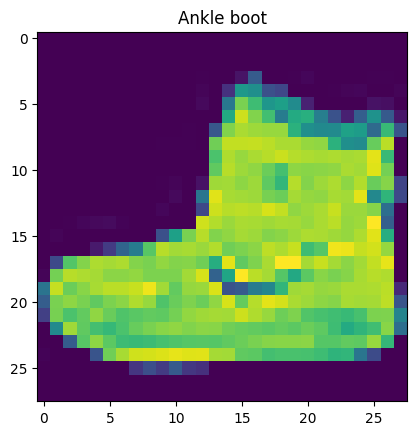

In [10]:
# visilise images


import matplotlib.pyplot as plt


image,label=train_data[0]

print(f"image_shape: {image.shape}")
plt.imshow(image.squeeze())
plt.title(class_names[label])

In [11]:
image.shape

torch.Size([1, 28, 28])

In [12]:
image.squeeze().shape

torch.Size([28, 28])

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

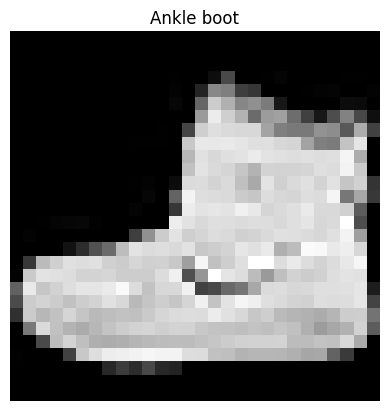

In [13]:
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

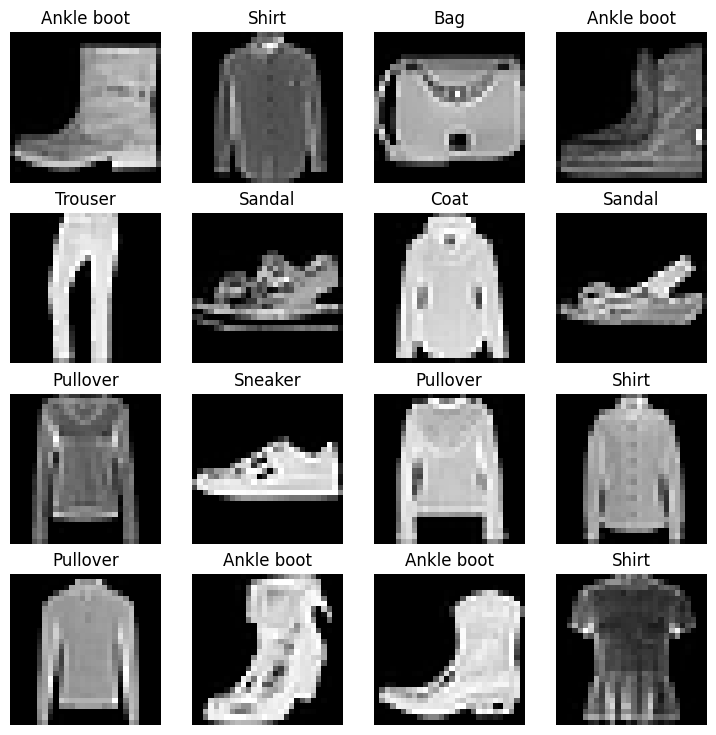

In [14]:
# plot more images

torch.manual_seed(42)

fig=plt.figure(figsize=(9,9))
rows,col=4,4
for i in range(1,rows*col+1):
  randome_idx=torch.randint(0,len(train_data),size=[1]).item()
  img,label=train_data[randome_idx]
  fig.add_subplot(rows,col,i)
  plt.imshow(img.squeeze(),cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)


In [15]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [16]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

## prepare DataLoader

Riht now, our data is in the form of Pytorch Darasets.

Data Loader turns our dataset into a Python iterable.

More specifically, we want to turn our data into batches (or mini batches)

` why would we do this: `

1. It is more cumputationally efficient, as in you computing hardware may not be able to look (store in mammory) at 60,000 images in one hit, so we break it down to 32 image batches at a time

2. It gives our neural networks more chances to update its gradients per epoch.


In [17]:
from torch.utils.data import DataLoader

# setup the batch size  hyperparameter

BATCH_SIZE = 32

# turn datasets into iterable (batches)

train_dataloader=DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader=DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)



In [18]:
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7c0cd0dbe420>,
 <torch.utils.data.dataloader.DataLoader at 0x7c0cd02e26c0>)

In [19]:
# let's checkout what we've created

print(f"Dataloaders: {train_dataloader,test_dataloader}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7c0cd0dbe420>, <torch.utils.data.dataloader.DataLoader object at 0x7c0cd02e26c0>)


In [20]:
# check out what's inside the training dataloader

train_features_batch,train_labels_batch = next(iter(train_dataloader))

train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

In [21]:
train_features_batch

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0157, 0.0000, 0.0039],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]]],


        [[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..

In [22]:
# create a flatten layer

flatten_model=nn.Flatten()

# get a single sample
x=train_features_batch[0]


# Flatten the sample

output=flatten_model(x)

#printout what happened
print(f"Shape before flattening: {x.shape}")
print(f"Shape After flattening: {output.shape}")



Shape before flattening: torch.Size([1, 28, 28])
Shape After flattening: torch.Size([1, 784])


In [23]:
from torch.nn.modules.linear import Linear
## train a simple model

class FashionMNISTV1(nn.Module):
  def __init__(self,input_shape: int, hidden_units: int, output_shape:int):
    super().__init__()
    self.layer_stack=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,out_features=hidden_units),
        nn.Linear(in_features=hidden_units,out_features=output_shape)
    )

  def forward(self,x):
    return self.layer_stack(x)



In [24]:
torch.manual_seed(42)

model_0=FashionMNISTV1(
    input_shape=784,
    hidden_units=10,
    output_shape=len(class_names)
)

In [25]:
model_0

FashionMNISTV1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [26]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

In [27]:
# dummy
with torch.inference_mode():
  dummy_x=torch.rand([1,1,28,28])
  model_0(dummy_x)



In [28]:
# loss and optimizer and accuracy

loss_fn=nn.CrossEntropyLoss()


# optimizer

optimizer=torch.optim.SGD(params=model_0.parameters(),lr=0.1)


def accuracy_fn(y_true,y_pred):
  correct=torch.eq(y_true,y_pred).sum().item()
  acc=(correct/len(y_pred))*100
  return acc

# Create a function to time our experiments

In [29]:
from timeit import default_timer as timer

def print_train_time(start:float,
                     end:float,
                     device:None):
  total_time=end-start
  print(f"Train time on {device}: {total_time:.3f} seconds")
  return total_time

## Creating a training loop and training a model on batch of data

1. Loop through epochs.
2. Loop through training batches, perform training steps, claculate the trainloss
3. Loop through testing batches, perform testing steps, calculating the test loss *per batch*
4. Print out what's happening
5.Time it all

In [30]:
from tqdm.auto import  tqdm


torch.manual_seed(42)

train_time_start_on_cpu=timer()

epochs=3

for epoch in tqdm(range(epochs)):

  print(f"epoch: {epoch}\n-------")

  train_loss=0
  train_acc=0

  # training
  for batch, (x,y) in enumerate(train_dataloader):
    #training
    model_0.train()
    # forward pass
    y_pred=model_0(x)

    # claculate the loss
    loss = loss_fn(y_pred,y)
    train_loss += loss

    #accuracy
    train_acc += accuracy_fn(y_true=y , y_pred=y_pred.argmax(dim=1))

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if batch % 400 == 0:
      print(f"Looked at {batch * len(x)}/{len(train_dataloader.dataset)} samples.")

  # devide toatal train loss by length of train dataloader
  # train_loss = train_loss/len(train_dataloader)
  train_loss /= len(train_dataloader)

  # calculate the average train accuracy per batch
  train_acc /= len(train_dataloader)


  # testing
  test_loss=0
  test_acc=0
  model_0.eval()
  with torch.inference_mode():
    for x_test,y_test in test_dataloader:
      # forward pass
      test_pred = model_0(x_test)

      # Calculate the loss
      test_loss += loss_fn(test_pred,y_test)

      # calculate accuracy

      test_acc += accuracy_fn(y_true=y_test,y_pred=test_pred.argmax(dim=1))

    #claculate the test_loss avg per batch
    test_loss /= len(test_dataloader)

    # claculate the test_acc avg per batch

    test_acc /= len(test_dataloader)

  # print out what's happening

  print(f"\n Train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

# calculate the training_tim

train_time_end_on_cpu = timer()

total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                            end=train_time_end_on_cpu,
                                            device=str(next(model_0.parameters()).device))


  0%|          | 0/3 [00:00<?, ?it/s]

epoch: 0
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train_loss: 0.5904 | train_acc: 79.1717 | test_loss: 0.5095 | test_acc: 82.0387
epoch: 1
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train_loss: 0.4763 | train_acc: 83.3200 | test_loss: 0.4799 | test_acc: 83.1969
epoch: 2
-------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

 Train_loss: 0.4550 | train_acc: 84.0517 | test_loss: 0.4766 | test_acc: 83.4265
Train time on cpu: 27.698 seconds


In [31]:
next(model_0.parameters()).device

device(type='cpu')

# Make prediction and get Model 0 results

In [32]:
torch.manual_seed(42)


def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn):
  loss,acc=0,0
  with torch.inference_mode():
    for x , y in tqdm(data_loader):
      y_pred = model_0(x)

      loss  += loss_fn(y_pred,y)

      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    loss /= len(data_loader)

    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_accuracy": acc}

model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_0_results


  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.47663888335227966,
 'model_accuracy': 83.42651757188499}

# Build Another Model and train it on gpu and see how much time effect it

In [33]:
!nvidia-smi

Tue Mar 31 08:23:38 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   53C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [34]:
torch.cuda.is_available()

True

In [35]:
# setup device-ignostic code

import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

device


'cuda'

# build a better model with non-linearity


In [36]:
from torch.nn.modules.container import Sequential
class FasionMNistModelV1(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                 out_features=output_shape),
        nn.ReLU()
    )

  def forward(self, x:torch.tensor):
    return self.layer_stack(x)


In [37]:
torch.manual_seed(42)

model_1 = FasionMNistModelV1(input_shape=784,
                             hidden_units=10,
                             output_shape=len(class_names)).to(device)

In [38]:
# create loss ,optimizer,evaluate matrics



loss_fn = nn.CrossEntropyLoss()


optimizer= torch.optim.SGD(params=model_1.parameters(),lr=0.1)



# functionizing training and evaluation/testing loops




In [39]:
# training


def train_step(model: nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss: torch.nn.Module,
               optimizer: torch.nn.Module,
               accuracy_fn,
               device: torch.device=device):
  """Perform  a training with model trying to learn on data_loader"""

  train_loss , train_acc = 0, 0

  model.train()


  for batch , (x,y) in tqdm(enumerate(data_loader)):
    x , y = x.to(device), y.to(device)
    y_pred = model(x)

    loss= loss_fn(y_pred,y)
    train_loss += loss

    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1)) # from logits -> prediction labels

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()


  train_loss /= len(data_loader)

  train_acc /= len(data_loader)

  print(f"Train_loss: {train_loss:.5f} | Train_acc: {train_acc:.2f}%\n")



In [40]:
# testing

def test_step(model: nn.Module,
              data_loader: torch.utils.data.DataLoader,
              test_loss: torch.nn.Module,
              test_acc: torch.nn.Module,
              device: torch.device=device):
  """Perform a testing loop step on model going over data_loader."""
  test_loss=0
  test_acc= 0

  model.eval()

  with torch.inference_mode():
    for x_test,y_test in tqdm(data_loader):
      x_test,y_test = x_test.to(device),y_test.to(device)
      y_pred = model(x_test)
      # loss= loss_fn(y_pred,y_test)
      test_loss += loss_fn(y_pred,y_test)
      test_acc += accuracy_fn(y_test,y_pred.argmax(dim=1))



    test_loss /= len(test_dataloader)

    # claculate the test_acc avg per batch

    test_acc /= len(test_dataloader)

    print(f"Test_loss: {test_loss:.5f} | Test_acc: {test_acc:.2f}%\n")



In [41]:
torch.manual_seed(42)

from timeit import default_timer as timer

train_time_start_on_gpu = timer()

epochs=3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n--------")
  train_step(model=model_1,
             data_loader=train_dataloader,
             loss= loss_fn,
             optimizer= optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_1,
             data_loader=test_dataloader,
             test_loss= loss_fn,
            #  optimizer= optimizer,
             test_acc=accuracy_fn,
             device=device)

train_time_end_on_gpu = timer()

total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,end=train_time_end_on_gpu,device=device)


  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
--------


0it [00:00, ?it/s]

Train_loss: 1.09199 | Train_acc: 61.34%



  0%|          | 0/313 [00:00<?, ?it/s]

...

Test_loss: 0.72300 | Test_acc: 74.24%

Epoch: 2
--------


0it [00:00, ?it/s]

Train_loss: 0.66776 | Train_acc: 76.08%



  0%|          | 0/313 [00:00<?, ?it/s]

Test_loss: 0.68743 | Test_acc: 75.66%

Train time on cuda: 32.710 seconds


In [42]:
model_0_results

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.47663888335227966,
 'model_accuracy': 83.42651757188499}

In [43]:
total_train_time_model_0

27.69780769199997

# get model_1 results dictionary

In [44]:
torch.manual_seed(42)


def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):
  loss,acc=0,0
  with torch.inference_mode():
    for x , y in tqdm(data_loader):

      x,y = x.to(device),y.to(device)
      y_pred = model(x)

      loss  += loss_fn(y_pred,y)

      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    loss /= len(data_loader)

    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_accuracy": acc}

model_1_results = eval_model(model=model_1,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)

model_1_results


  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FasionMNistModelV1',
 'model_loss': 0.68743497133255,
 'model_accuracy': 75.65894568690096}

In [45]:
model_0_results

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.47663888335227966,
 'model_accuracy': 83.42651757188499}

# Build a Convolutional Neural Networks

* to learn more check out url: https://poloclub.github.io/cnn-explainer/#article-relu

In [46]:
class FasionMNISTModelV2(nn.Module):
  def __init__(self,input_shape:int, hidden_units:int, output_shape:int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=3,
            stride=1,
            padding=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7,
                  out_features=output_shape),


    )

  def forward(self,x):
    x = self.conv_block_1(x)
    # print(f"output_shape of cpnv_block_1: {x.shape}")
    x = self.conv_block_2(x)
    # print(f"output_shape of cpnv_block_2: {x.shape}")
    x = self.classifier(x)
    # print(f"output_shape of classifier: {x.shape}")

    return x



In [47]:
torch.manual_seed(42)

model_2 = FasionMNISTModelV2(input_shape=1,
                             hidden_units=10,
                             output_shape=len(class_names)).to(device)



In [48]:
model_2

FasionMNISTModelV2(
  (conv_block_1): Sequential(
    (0): Conv2d(1, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=490, out_features=10, bias=True)
  )
)

In [49]:
torch.manual_seed(42)


# create a batch of images

images = torch.randn(size=(32,3,64,64))

test_image = images[0]

print(f"Image Batch Shape: {images.shape}")
print(f"Sigle Image Shape: {test_image.shape}")
print(f"sing Image:\n {test_image}")






Image Batch Shape: torch.Size([32, 3, 64, 64])
Sigle Image Shape: torch.Size([3, 64, 64])
sing Image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0.

In [50]:
test_image.shape

torch.Size([3, 64, 64])

In [51]:
# single conv2d layer
torch.manual_seed(42)
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size = 3,
                       stride=1,
                       padding=0)

# pass the data through the convolutional layer

conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

In [52]:
# stepping through nn.Maxpool2d

print(f"test_image shape: {test_image.shape}")

max_pool_layer = nn.MaxPool2d(kernel_size=2)

# lets pass data through conv layer

test_image_through_conv = conv_layer(test_image)

print(f"shape after conv_layer: {test_image_through_conv.shape}")

# pass the data through maxpool layer

test_image_through_max_pool = max_pool_layer(test_image_through_conv)

print(f"shape after maxpool_layer: {test_image_through_max_pool.shape}")


test_image shape: torch.Size([3, 64, 64])
shape after conv_layer: torch.Size([10, 62, 62])
shape after maxpool_layer: torch.Size([10, 31, 31])


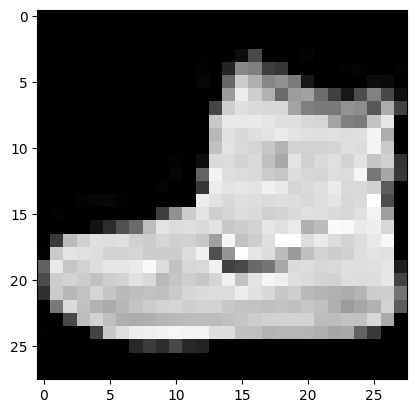

In [53]:
plt.imshow(image.squeeze(),cmap="gray")

In [54]:
# pass image through model
image.shape

torch.Size([1, 28, 28])

In [55]:
torch.manual_seed(42)

rand_image_tensor = torch.randn(size=(1,1,28,28))
rand_image_tensor.shape

torch.Size([1, 1, 28, 28])

In [56]:
rand_image_tensor = rand_image_tensor.to(device)
model_2(rand_image_tensor)

tensor([[ 0.0505, -0.0729,  0.0821, -0.0451, -0.0044,  0.0383,  0.0061, -0.0016,
         -0.0127, -0.0081]], device='cuda:0', grad_fn=<AddmmBackward0>)

In [57]:
10*7*7

490

# training a CNN

In [58]:
# setup loss functions


loss_fun = nn.CrossEntropyLoss()


optimizer = torch.optim.SGD(params = model_2.parameters(),lr=0.1)


In [59]:
# training loop

torch.manual_seed(42)
torch.cuda.manual_seed(42)

from timeit import default_timer as Timer

train_time_start_model_2 = timer()

epochs = 3

for epoch in range(epochs):
  train_step(model= model_2,
             data_loader=train_dataloader,
             loss=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            test_loss=loss_fn,
            test_acc=accuracy_fn,
            device=device)


train_time_end_model_2 = timer()

total_train_time_model_2 = print_train_time(start= train_time_start_model_2,
                                            end=train_time_end_model_2,
                                            device=device)



0it [00:00, ?it/s]

Train_loss: 0.59139 | Train_acc: 78.56%



  0%|          | 0/313 [00:00<?, ?it/s]

Test_loss: 0.39336 | Test_acc: 85.93%



0it [00:00, ?it/s]

...

Test_loss: 0.39060 | Test_acc: 85.91%



0it [00:00, ?it/s]

Train_loss: 0.32617 | Train_acc: 88.28%



  0%|          | 0/313 [00:00<?, ?it/s]

Test_loss: 0.33750 | Test_acc: 87.77%

Train time on cuda: 37.145 seconds


In [60]:
# get model_2 results

torch.manual_seed(42)


def eval_model(model:torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn:torch.nn.Module,
               accuracy_fn,
               device:torch.device=device):
  loss,acc=0,0
  with torch.inference_mode():
    for x , y in tqdm(data_loader):

      x,y = x.to(device),y.to(device)
      y_pred = model(x)

      loss  += loss_fn(y_pred,y)

      acc += accuracy_fn(y, y_pred.argmax(dim=1))

    loss /= len(data_loader)

    acc /= len(data_loader)

  return {"model_name": model.__class__.__name__, # only works when model was created with a class
          "model_loss": loss.item(),
          "model_accuracy": acc}


model_2_results = eval_model(
    model = model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FasionMNISTModelV2',
 'model_loss': 0.3374977111816406,
 'model_accuracy': 87.76956869009585}

In [61]:
model_0_results

{'model_name': 'FashionMNISTV1',
 'model_loss': 0.47663888335227966,
 'model_accuracy': 83.42651757188499}

In [62]:
model_1_results

{'model_name': 'FasionMNistModelV1',
 'model_loss': 0.68743497133255,
 'model_accuracy': 75.65894568690096}

In [63]:
import pandas as pd

compare_results = pd.DataFrame([model_0_results,
                                model_1_results,
                                model_2_results])

In [64]:
compare_results

,model_name,model_loss,model_accuracy
0,FashionMNISTV1,0.476639,83.426518
1,FasionMNistModelV1,0.687435,75.658946
2,FasionMNISTModelV2,0.337498,87.769569


In [65]:
compare_results["training_time"] = [total_train_time_model_0,
                                    total_train_time_model_1,
                                    total_train_time_model_2]

In [66]:
compare_results

,model_name,model_loss,model_accuracy,training_time
0,FashionMNISTV1,0.476639,83.426518,27.697808
1,FasionMNistModelV1,0.687435,75.658946,32.709564
2,FasionMNISTModelV2,0.337498,87.769569,37.144627


Text(0, 0.5, 'model')

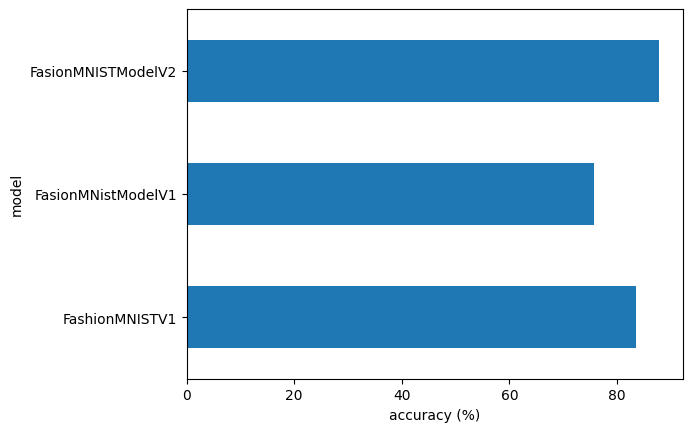

In [67]:
# visualize

compare_results.set_index("model_name")["model_accuracy"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")
